In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
import numpy as np
from qiskit.quantum_info import DensityMatrix, state_fidelity
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

# Infidelity to Error Rates

In [12]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

# Defining Numpy Matrices

In [3]:
hadamard = [[1/np.sqrt(2),1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]]
identity = [[1,0], [0,1]]

theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
ry_theta = [[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]]

cz = [[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,-1]]

# Functions

In [4]:
def state_prep(matrix):
    # Apply R_y(theta) to all three qubits.
    matrix = np.array(matrix)
    ry_ry_ry = np.kron(ry_theta, np.kron(ry_theta, ry_theta))
    answer = ry_ry_ry @ matrix @ ry_ry_ry.conj().T
    return answer / np.trace(answer)

# Each layer corresponds to a time step in the three-qubit MSD circuit
def first_layer(matrix):
    # Apply CZ on qubits 0 and 1, and H on qubit 2.
    matrix = np.array(matrix)
    cz_h = np.kron(cz, hadamard)
    answer = cz_h @ matrix @ cz_h.conj().T
    return answer / np.trace(answer)


def second_layer(matrix):
    # Apply CZ on qubits 1 and 2.
    matrix = np.array(matrix)
    i_cz = np.kron(identity, cz)
    answer = i_cz @ matrix @ i_cz.conj().T
    return answer / np.trace(answer)


def third_layer(matrix):
    # Apply H to qubits 0 and 1.
    matrix = np.array(matrix)
    h_h_i = np.kron(hadamard, np.kron(hadamard, identity))
    answer = h_h_i @ matrix @ h_h_i.conj().T 
    return answer / np.trace(answer)


def meas(matrix):
    # Project qubits 0 and 1 onto |00>.
    matrix = np.array(matrix)
    two_qubit_projector = [[1, 0, 0, 0],
                           [0, 0, 0, 0],
                           [0, 0, 0, 0],
                           [0, 0, 0, 0]]
    projector = np.kron(two_qubit_projector, identity)
    answer = projector @ matrix @ projector.conj().T
    return answer / np.trace(answer)


def noisy_state_prep1(matrix, error_prob):
    # Apply noisy R_y(theta) on qubit 1.
    matrix = np.array(matrix)
    i_ry_i = np.kron(identity, np.kron(ry_theta, identity))
    new_dm = i_ry_i @ matrix @ i_ry_i.conj().T 

    # Replace qubit 1 by the maximally mixed state with probability error_prob.
    mixed = np.kron(
        np.matmul([[1], [0]], [[1, 0]]),
        np.kron(np.asarray(identity) / 2, np.matmul([[1], [0]], [[1, 0]]))
    )
    
    answer = (1 - error_prob) * new_dm + error_prob * mixed
    return answer / np.trace(answer)


def noisy_state_prep2(matrix, error_prob):
    # Apply noisy R_y(theta) on qubit 0.
    matrix = np.array(matrix)
    ry_i_i = np.kron(ry_theta, np.kron(identity, identity))
    new_dm = ry_i_i @ matrix @ ry_i_i.conj().T 

    # Trace out qubit 0, then replace it by the maximally mixed state.
    traced_dm = new_dm[0:4, 0:4] + new_dm[4:8, 4:8]
    answer = (1 - error_prob) * new_dm + error_prob * np.kron(np.asarray(identity) / 2, traced_dm)
    
    return answer / np.trace(answer)


def noisy_state_prep3(matrix, error_prob):
    # Apply noisy R_y(theta) on qubit 2.
    matrix = np.array(matrix)
    i_i_ry = np.kron(identity, np.kron(identity, ry_theta))
    new_dm = i_i_ry @ matrix @ i_i_ry.conj().T 
    
    # Trace out qubit 2, then replace it by the maximally mixed state.
    traced_dm = []
    for i in range(0, 7, 2):
        temp = []
        for j in range(0, 7, 2):
            temp.append(new_dm[i, j] + new_dm[i + 1, j + 1])
        traced_dm.append(temp)
    traced_dm = np.array(traced_dm)
    
    answer = (1 - error_prob) * new_dm + error_prob * np.kron(traced_dm, np.asarray(identity) / 2)
    return answer / np.trace(answer)


def noisy_state_prep(matrix, error_prob):
    # Apply noisy state preparation to all three qubits.
    output = noisy_state_prep1(matrix, error_prob)
    output = noisy_state_prep2(output, error_prob)
    output = noisy_state_prep3(output, error_prob)
    
    return output

# Simulations

Ideal circuits

In [5]:
# Construct |000><000|.
one_q_zero_dm = np.matmul([[1], [0]], [[1, 0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

# Apply R_y(theta) to the third qubit.
i_i_ry = np.kron(identity, np.kron(identity, ry_theta))
ideal = i_i_ry @ ideal @ i_i_ry.conj().T 

# Normalize the density matrix.
ideal /= np.trace(ideal)

In [6]:
ideal_input = one_q_zero_dm
ideal_input = np.asarray(ry_theta) @ ideal_input @ np.asarray(ry_theta).conj().T
ideal_input /= np.trace(ideal_input)

noisy circuits

In [7]:
# Set the state-preparation error probability.
error_prob = 0.3

# Construct the initial density matrix |000><000|.
one_q_zero_dm = np.matmul([[1], [0]], [[1, 0]])
init = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

# Apply noisy R_y(theta) state preparation to all three qubits.
output = noisy_state_prep(init, error_prob)

# Apply the three circuit layers.
output = first_layer(output)
output = second_layer(output)
output = third_layer(output)

# Post-select on the accepted measurement outcome.
final = meas(output)

In [8]:
input = one_q_zero_dm
input = np.asarray(ry_theta) @ input @ np.asarray(ry_theta).conj().T
input = (1-error_prob)*input + error_prob *np.eye(2)/2
input /= np.trace(input)

fidelity comparisons

In [9]:
dm_final = DensityMatrix(final)
dm_ideal = DensityMatrix(ideal)
dm_input = DensityMatrix(input)
dm_ideal_input = DensityMatrix(ideal_input)

output_fidelity = state_fidelity(dm_final, dm_ideal)
input_fidelity = state_fidelity(dm_input, dm_ideal_input)
print(f"For Depolarizing Error Probability = {error_prob}")
print(f"Output Fidelity = {output_fidelity}")
print(f"Input Fidelity = {input_fidelity}")

For Depolarizing Error Probability = 0.3
Output Fidelity = 0.8514144407454767
Input Fidelity = 0.8500000025583442


Graphing

In [10]:
dm_ideal = DensityMatrix(ideal)
dm_ideal_input = DensityMatrix(ideal_input)

In [22]:
# Sweep over depolarizing error probabilities.
depol_error_list = np.linspace(0.2, 0.5, 1_000)

output_infidelity_list = []
input_infidelity_list = []

for e in depol_error_list:
    # Construct the initial density matrix |000><000|.
    one_q_zero_dm = np.matmul([[1], [0]], [[1, 0]])
    init = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

    # Run the noisy distillation circuit.
    output = noisy_state_prep(init, e)
    output = first_layer(output)
    output = second_layer(output)
    output = third_layer(output)
    final = meas(output)

    # Convert the post-selected output to a DensityMatrix.
    dm_final = DensityMatrix(final)

    # Construct the noisy single-qubit input state.
    input = one_q_zero_dm
    input = np.asarray(ry_theta) @ input @ np.asarray(ry_theta).conj().T
    input = (1 - e) * input + e * np.eye(2) / 2
    input /= np.trace(input)
    dm_input = DensityMatrix(input)

    # Store input and output infidelities.
    output_infidelity_list.append(1 - state_fidelity(dm_final, dm_ideal))
    input_infidelity_list.append(1 - state_fidelity(dm_input, dm_ideal_input))

output_error_rate = inf_to_error(output_infidelity_list, 1)

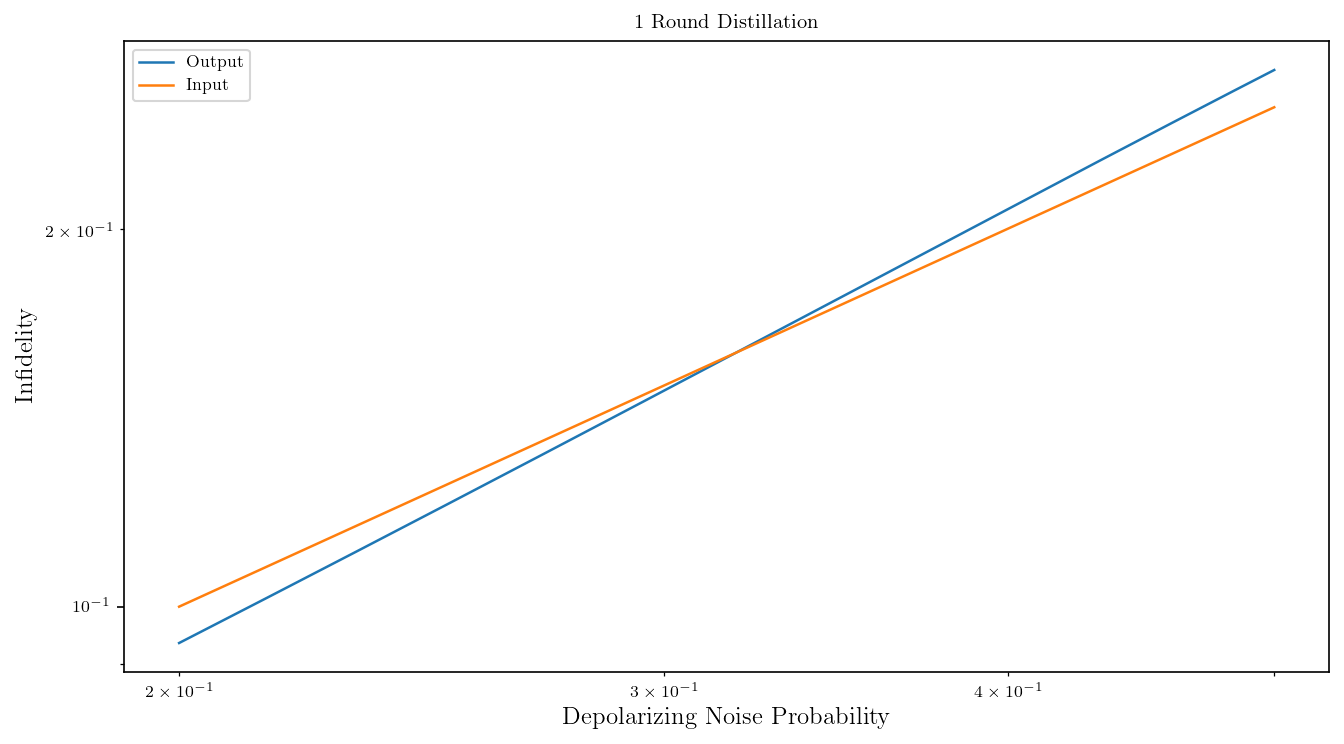

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(depol_error_list, output_infidelity_list, label='Output')
plt.plot(depol_error_list, input_infidelity_list, label='Input')
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title("1 Round Distillation")
plt.tight_layout()
plt.legend()
plt.show()

In [17]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

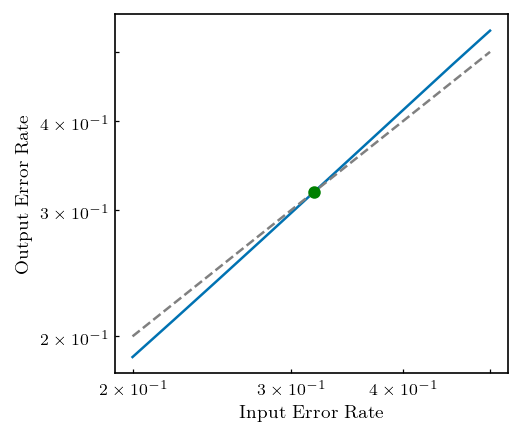

In [28]:
yscale = 1e-2
xscale = 1e-2

fig, ax = plt.subplots(figsize=(3.375, 2.8))

ax.plot(depol_error_list, output_error_rate, color='#0072B2', linestyle='-')
ax.plot(depol_error_list, depol_error_list,  color='gray', linestyle='--')

x_arr = np.asarray(depol_error_list)
y1_arr = np.asarray(depol_error_list)
y2_arr = np.asarray(output_error_rate)

# Difference between the two curves
diff = y2_arr - y1_arr

# Find where the sign changes
idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

if len(idx) > 0:
    i = idx[0]

    # Linear interpolation for intersection
    x_intersection = x_arr[i] - diff[i] * (x_arr[i+1] - x_arr[i]) / (diff[i+1] - diff[i])
    y_intersection = np.interp(x_intersection, x_arr, y1_arr)

    # Plot green dot
    ax.plot(
        x_intersection,
        y_intersection,
        'o',
        color='green',
        markersize=5,
        zorder=5
    )

ax.set_xscale('log')
ax.set_yscale('log')

ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.set_ylabel("Output Error Rate")
ax.set_xlabel("Input Error Rate")

# Remove ticks on the top and right
ax.tick_params(which='both', direction='in', top=False, right=False)

fig.tight_layout(pad=0.4)

In [29]:
print(y_intersection)

0.318723349370938


# Approximating the threshold noise probability and infidelity

In [24]:
thr = 0
for i in range(len(depol_error_list)):
    if (output_infidelity_list[i] >= input_infidelity_list[i]):
        thr = depol_error_list[i]
        print(thr)
        break

0.3187987987987988


In [25]:
def error_to_inf(error_list, num_qubits):
    inf_list = []
    dim = 2**num_qubits
    for error in error_list:
        inf_list.append(error * (dim - 1)/dim)
        
    return inf_list

In [26]:
print(f"Infidelity Threshold = {error_to_inf([thr], 1)[0]}")

Infidelity Threshold = 0.1593993993993994


# Saving Data

In [30]:
np.savez(
    "threshold.npz",
    input_error_rate=depol_error_list,
    output_error_rate=output_error_rate,
    intersection=y_intersection
)